# **Inverting Integrals**

The next code inverts the integral $F(u) = \int_1^u \frac{1}{x} \, dx $, without assuming that the integral can be evaluated as log function.

I0000 00:00:1785861808.276552   13855 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785861811.354380   13855 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785861834.126788   13855 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/efra/anaconda3/envs/dl4physics/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1785861846.909327   13855 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA er

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 1.9385
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 1.1872
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.1299
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1950
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1389 
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.1037
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0523
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0972 
Epoch 9/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0686
Epoch 10/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0635
Epoch 11/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0573
Epoch 12/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0524
Epoch 13/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0498 
Epoch 14/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0471
Epoch 15/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0484
Epoch 16/500


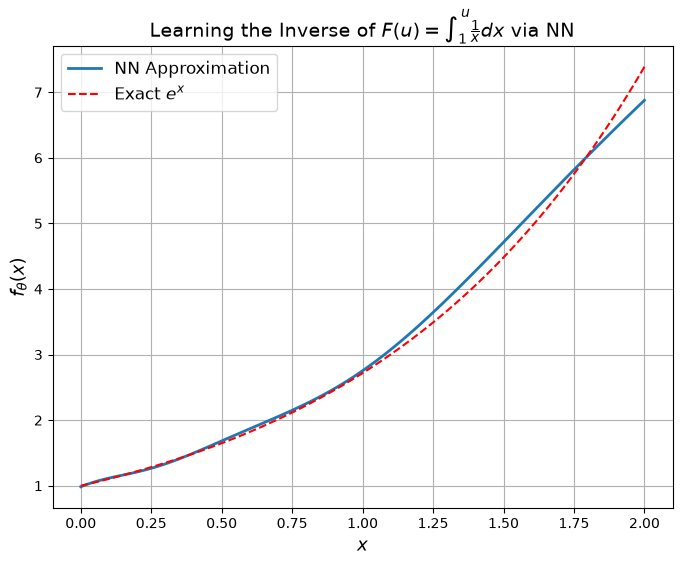

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Regularization weight for enforcing the initial condition
lambda_ic = 1.0

# Training data: u values in [0, 2]
x_train = np.linspace(0, 2, 100).reshape(-1, 1).astype(np.float32)
dummy_target = x_train.copy()

# Define the model: approximates the inverse function
model = Sequential([
    Dense(50, activation='tanh', input_shape=(1,)),
    Dense(50, activation='tanh'),
    Dense(1)
])

# Vectorized numerical integral: ∫_1^{f_theta(u)} 1/x dx
def vectorized_integral(f_vals, num_points=100):
    a = 1.0
    b = tf.maximum(f_vals, a + 1e-3)  # ensure f_vals > 1
    s = tf.linspace(0.0, 1.0, num_points)  # shape (num_points,)
    s = tf.reshape(s, (1, num_points))  # (1, M)
    b = tf.reshape(b, (-1, 1))          # (N, 1)

    # Broadcast to compute x values per sample
    x_vals = a + s * (b - a)  # shape (N, M)
    integrand = 1.0 / x_vals
    dx = (b - a) / num_points
    integral = tf.reduce_sum(integrand, axis=1, keepdims=True) * dx  # shape (N,1)
    return integral

# Custom loss using numerical integration
def custom_loss(y_true, y_pred):
    integral_vals = vectorized_integral(y_pred)
    equation_loss = tf.reduce_mean(tf.square(integral_vals - y_true))

    # Initial condition loss: f_theta(0) ≈ 1
    f0 = model(tf.constant([[0.0]], dtype=tf.float32))
    ic_loss = tf.square(f0 - 1.0)

    return equation_loss + lambda_ic * ic_loss

# Compile and train the model
model.compile(optimizer=Adam(learning_rate=0.01), loss=custom_loss)
model.fit(x_train, dummy_target, epochs=500, batch_size=32, verbose=1)

# Plot results
x_test = np.linspace(0, 2, 100).reshape(-1, 1).astype(np.float32)
y_pred = model.predict(x_test)
y_true = np.exp(x_test)

plt.figure(figsize=(8, 6))
plt.plot(x_test, y_pred, label="NN Approximation", linewidth=2)
plt.plot(x_test, y_true, label="Exact $e^x$", linestyle='dashed', color='red')
plt.title("Learning the Inverse of $F(u) = \\int_1^u \\frac{1}{x}dx$ via NN", fontsize=14)
plt.xlabel("$x$", fontsize=13)
plt.ylabel("$f_\\theta(x)$", fontsize=13)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()


The next code uses neural nets to invert the integral $$ \int_0^{\cos \alpha(t)} \frac{dx}{\sqrt{x(1-x^2)}} =t. $$

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.9396
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0222
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0019
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - loss: 3.7807e-04
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - loss: 1.3836e-04
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - loss: 7.6350e-05
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 5.4399e-05
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 4.4993e-05
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 4.0427e-05
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 3.7971e-05
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 3.6498e-05
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: 3.5498e-05
Epoch 13/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 3.4727e-05
Epoch 14/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - loss: 3.4066e-05
Epoch 15/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 1

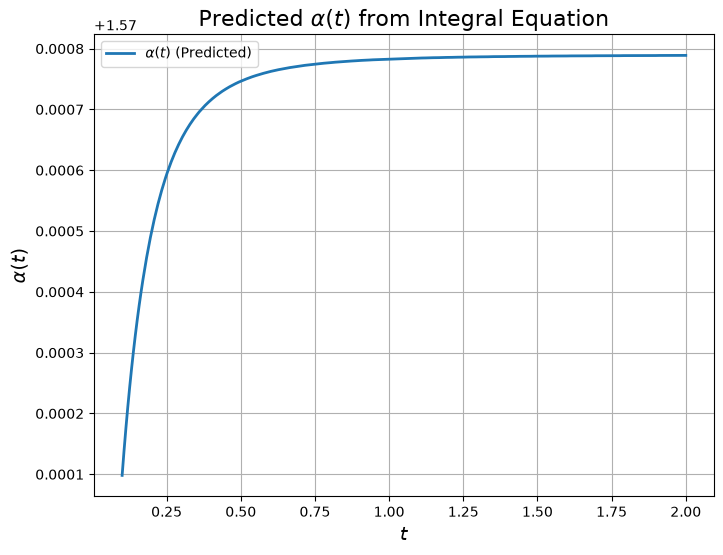

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(0)
tf.random.set_seed(0)

# Riemann approximation parameters
num_points = 200
epsilon = 1e-4

# Define integrand safely
def integrand(x):
    return 1.0 / tf.sqrt(x * (1.0 - x**2) + epsilon)

# Vectorized Riemann approximation of integral ∫₀^cos(α(t)) 1/√(x(1 - x²)) dx
def approximate_integral_vectorized(cos_alpha_vals):
    def integrate_single(upper):
        upper = tf.clip_by_value(upper, epsilon, 1.0 - epsilon)
        x_vals = tf.linspace(epsilon, upper, num_points)
        dx = (upper - epsilon) / tf.cast(num_points, tf.float32)
        integral = tf.reduce_sum(integrand(x_vals)) * dx
        return integral
    return tf.map_fn(integrate_single, cos_alpha_vals, fn_output_signature=tf.float32)

# Training data
t_train = np.linspace(0.1, 2.0, 200).reshape(-1, 1).astype(np.float32)
dummy_target = np.zeros_like(t_train)

# Define model
model = Sequential([
    Input(shape=(1,)),
    Dense(50, activation='tanh'),
    Dense(50, activation='tanh'),
    Dense(1, activation='sigmoid')  # Output in (0,1) ~ cos(alpha)
])

# Custom loss using Riemann integration
def custom_loss(y_true, y_pred):
    cos_alpha = tf.squeeze(y_pred, axis=1)
    integrals = approximate_integral_vectorized(cos_alpha)
    residual = integrals - tf.squeeze(y_true, axis=1)
    return tf.reduce_mean(tf.square(residual))

# Compile and train
model.compile(optimizer=Adam(learning_rate=0.01), loss=custom_loss)
model.fit(t_train, dummy_target, epochs=30, batch_size=32, verbose=1)

# Predict and plot
t_vals = np.linspace(0.1, 2.0, 300).reshape(-1, 1).astype(np.float32)
cos_alpha_pred = model.predict(t_vals)
alpha_pred = np.arccos(np.clip(cos_alpha_pred, 0, 1))

plt.figure(figsize=(8, 6))
plt.plot(t_vals, alpha_pred, label=r"$\alpha(t)$ (Predicted)", linewidth=2)
plt.title(r"Predicted $\alpha(t)$ from Integral Equation", fontsize=16)
plt.xlabel("$t$", fontsize=14)
plt.ylabel(r"$\alpha(t)$", fontsize=14)
plt.grid(True)
plt.legend()
plt.show()
